In [19]:
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}
%load_ext autoreload
%autoreload 2

import pickle
import time as t
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import time as t
from scipy.signal import fftconvolve, oaconvolve
from scipy.ndimage import zoom
import MulensModel as mm

from IRSMicroLensing import IRSCaustics as IRSC
from IRSMicroLensing import IRSFunctions as IRSF

import numexpr

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
args = {
    'sep2': '0.8',
    'angle2': '45',
    'planet_mass_ratio': '0.01',
    'origin': 'triple_offset'  # Options: 'triple_offset', 'binary_offset', 'cm'

}

''' Preparing lens parameters '''
# Big planet parameters
s1 = 0.8
alpha1 = 0
q1 = 1e-3

# Small planet parameters
s2 = np.float64(numexpr.evaluate(args['sep2']).item())
alpha2 = np.float64(args['angle2'])
q2 = np.float64(args['planet_mass_ratio']) * q1

print(f'q1 = {q1}')
print(f'q2 = {q2}')
print(f's1 = {s1}')
print(f's2 = {s2}')
print(f'alpha1 = {alpha1}')
print(f'alpha2 = {alpha2}')

# Defining single lens attributes
single_lens_attributes = np.array([
    [0, 0, 1]
])

# Defining binary lens attributes
binary_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
])

# Triple lens attributes
triple_lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
    [s2*np.cos(np.deg2rad(alpha2)), s2*np.sin(np.deg2rad(alpha2)), q2]
])

# Rotation matrix for first planet
first_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha1)), -np.sin(np.deg2rad(alpha1))],
    [np.sin(np.deg2rad(alpha1)), np.cos(np.deg2rad(alpha1))]
])

# Rotation matrix for second planet
second_planet_DCM = np.array([
    [np.cos(np.deg2rad(alpha2)), -np.sin(np.deg2rad(alpha2))],
    [np.sin(np.deg2rad(alpha2)), np.cos(np.deg2rad(alpha2))]
])

# Calculating translation of coordinate origin for each planet
q1 = triple_lens_attributes[1, 2]
q2 = triple_lens_attributes[2, 2]

delta1_rot = np.array([q1 / ((1 + q1) * (s1 + 1/s1)), 0]).reshape(-1, 1)
delta2_rot = np.array([q2 / ((1 + q2) * (s2 + 1/s2)), 0]).reshape(-1, 1)

delta1 = np.dot(first_planet_DCM, delta1_rot).reshape(2)
delta2 = np.dot(second_planet_DCM, delta2_rot).reshape(2)

total_offset = (q1*delta1 + q2*delta2)/(q1 + q2)
print(f'Total offset: {total_offset}')
print(f'Binary offset: {delta1}')

CM_sum = 0

for i in range(2):
    CM_sum += binary_lens_attributes[i, :2] * binary_lens_attributes[i, 2]

total_M = np.sum(binary_lens_attributes[:, 2])

lens_CM = CM_sum / total_M

print(f'CM of the triple lens: {lens_CM}')

q1 = 0.001
q2 = 1e-05
s1 = 0.8
s2 = 0.8
alpha1 = 0
alpha2 = 45.0
Total offset: [4.82526785e-04 3.41511572e-08]
Binary offset: [0.00048732 0.        ]
CM of the triple lens: [0.0007992 0.       ]


In [21]:
# Single lens
single_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/single_1e11.pkl')

# Binary lens
binary_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/binary_1e11.pkl')

ang_width = single_lens.ang_width
pixels = single_lens.pixels
ang_res = ang_width / (pixels - 1)

# Calculating area of annulus
A_ann = np.pi * (single_lens.y_plus**2 - single_lens.y_minus**2)

# Calculating ray density within annulus
sigma_ann = single_lens.num_rays / A_ann

# Calculating area of pixel
A_pix = (ang_res * 1.0)**2
old_A_pix = (single_lens.ang_res * 1.0)**2

(208, 208)


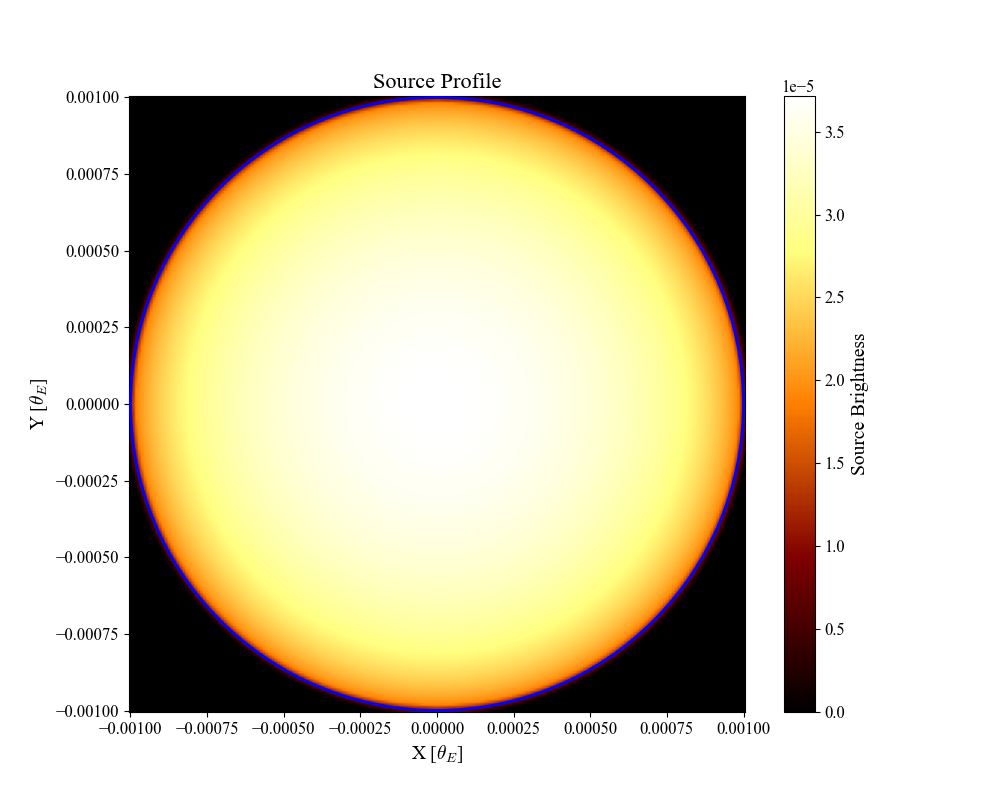

In [22]:
scale_factor = 4
new_ang_res = ang_res / scale_factor
radius = 1e-3
LD = 0.5

source_profile = IRSF.IRSFunctions.source_profile(ang_res=single_lens.param_dict['ang_res'], rad=radius, profile_type='LD', LD=LD, scale_factor=scale_factor, supersample=10)
print(source_profile.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

img = ax.imshow(source_profile, cmap='afmhot', extent=[-radius - new_ang_res / 2, radius + new_ang_res / 2, -radius - new_ang_res / 2, radius + new_ang_res / 2])
plt.colorbar(img, ax=ax, label='Source Brightness')

source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
ax.add_patch(source_patch)

ax.set_xlabel('X [$\\theta_E$]')
ax.set_ylabel('Y [$\\theta_E$]')
ax.set_title('Source Profile')

ax.set_aspect('equal')

plt.show()

In [23]:
def einstein_to_index(x_pix, y_pix, ang_width, pixels):
    ang_res = ang_width / (pixels - 1)

    if pixels % 2 == 0:  # even number of pixels
        x_ind = (x_pix + ang_width / 2) / ang_res
        y_ind = (ang_width / 2 + y_pix) / ang_res
    
    else:  # odd number of pixels
        x_ind = (x_pix + ang_width / 2) / ang_res
        y_ind = (ang_width / 2 + y_pix) / ang_res

    return x_ind, y_ind

def index_to_einstein(x_ind, y_ind, ang_width, pixels):
    ang_res = ang_width / (pixels - 1)

    if pixels % 2 == 0:
        # Even number of pixels
        x_pix = -ang_width / 2 + x_ind * ang_res
        y_pix = -ang_width / 2 + y_ind * ang_res
    else:
        # Odd number of pixels
        x_pix = -ang_width / 2 + x_ind * ang_res
        y_pix = -ang_width / 2 + y_ind * ang_res

    return x_pix, y_pix

In [24]:
import numpy as np
from scipy.ndimage import map_coordinates

def lightcurve_calculator(u, alpha, ang_width, map_array: np.ndarray, lens_CM: tuple | np.ndarray=(0, 0), offset: tuple | np.ndarray=(0, 0), n_samples: int=1e4):
    '''
    Calculates the light curve by interpolating magnification values along a line.

    Parameters
    ----------
    u : float
        Impact parameter from the lens center of mass
    alpha : float
        Angle of source trajectory from x axis in degrees
    ang_width : float
        Angular width of magnification map
    map_array : 2D NDArray
        Magnification map array
    lens_CM: 2-element tuple or NDArray
        Center of mass of lens system in scientific coordinates
    offset : 2-element tuple or NDArray, optional
        Current origin offset from star position in scientific coordinates
    n_samples : int, optional
        Number of interpolated samples along the trajectory

    Returns
    -------
    intersections : 2x2 NDArray
        First row is starting point, second row is ending point (in scientific coordinates)
    (xs, ys) : tuple of 1D NDArrays
        Scientific coordinates of the line
    times : 1D NDArray
        Array of time values along trajectory
    line_values : 1D NDArray
        Interpolated magnification values along the line
    '''
    u0 = u # Negate u to match the convention of the lensing model

    n_samples = int(n_samples)  # Ensure n_samples is an integer

    alpha = np.deg2rad(alpha)
    intersections = []

    # Center of trajectory in inertial frame
    x0_inert = u0 * np.sin(alpha)
    y0_inert = -u0 * np.cos(alpha)

    # Convert to COM frame (scientific coordinates)
    x0 = x0_inert - offset[0] + lens_CM[0]
    y0 = y0_inert - offset[1] + lens_CM[1]

    dx = np.cos(alpha)
    dy = np.sin(alpha)

    # Find entry and exit points of the trajectory through the square map
    for x_edge in [-ang_width/2, ang_width/2]:
        t = (x_edge - x0) / dx
        y = y0 + t*dy
        if -ang_width/2 <= y <= ang_width/2:
            intersections.append((x_edge, y))

    for y_edge in [-ang_width/2, ang_width/2]:
        t = (y_edge - y0) / dy
        x = x0 + t*dx
        if -ang_width/2 <= x <= ang_width/2:
            intersections.append((x, y_edge))

    if len(intersections) < 2:
        raise ValueError("Trajectory does not intersect the magnification map bounds.")

    intersections = np.array(intersections[:2])  # First two valid ones

    # Get start and end in scientific coordinates
    start = intersections[0]
    end = intersections[1]

    # Distance from center point to start/end in Einstein time units (assuming constant velocity)
    t_E_start = -np.hypot(*(start - [x0, y0]))
    t_E_end = np.hypot(*(end - [x0, y0]))
    times = np.linspace(t_E_start, t_E_end, n_samples)

    # Interpolated coordinates in scientific space
    xs = np.linspace(start[0], end[0], n_samples)
    ys = np.linspace(start[1], end[1], n_samples)

    # Convert to pixel indices (float) for interpolation
    pixels = map_array.shape[0]
    x_idx, y_idx = einstein_to_index(xs, ys, ang_width, pixels)

    # Interpolate using bilinear sampling (order=1)
    coords = np.vstack([y_idx, x_idx])  # row-major (y first)
    line_values = map_coordinates(map_array, coords, order=2, mode='nearest')

    return intersections, (xs, ys), (x0, y0), times, line_values

In [25]:
new_ang_res

np.float64(9.605202201500352e-06)

#### Light curve testing

In [8]:
test_pixels = 10
test_ang_width = 2.0
test_ang_res = test_ang_width / (test_pixels - 1)

random_map = np.random.randint(0, 5, (test_pixels, test_pixels)).astype(np.float64)

In [9]:
einstein_to_index(-1, 0, test_ang_width, test_pixels)

(0.0, 4.5)

[0.]
[-1.] [-0.15]


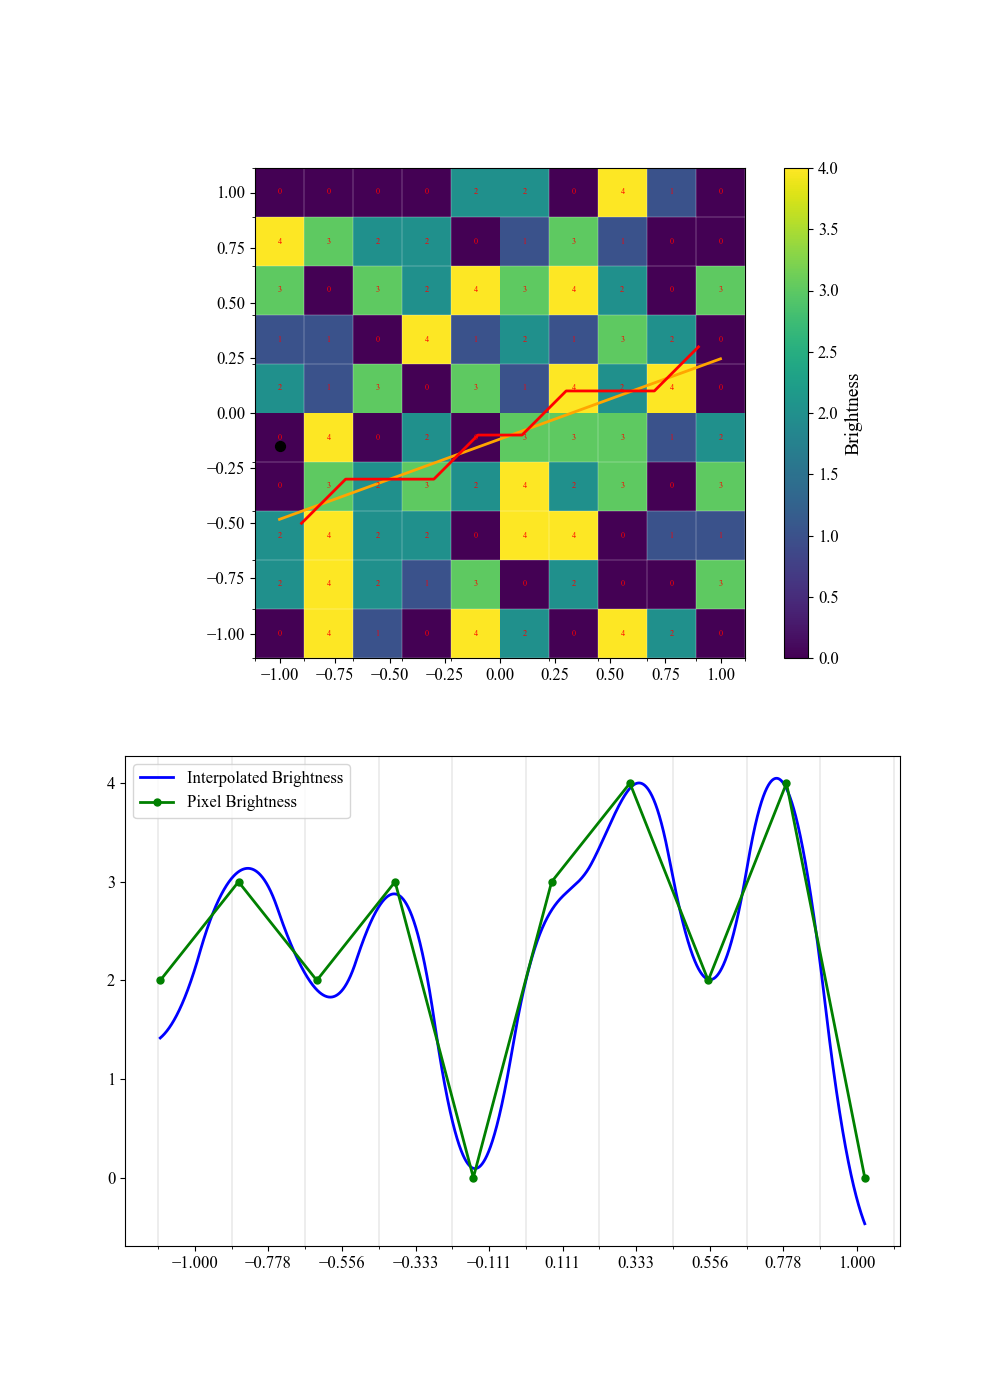

In [10]:
u = 0.11111111111
alpha = 20

test_intersections, (test_xs, test_ys), (x_idx, y_idx), test_times, test_brightnesses = lightcurve_calculator(u=u, alpha=alpha, ang_width=test_ang_width, map_array=random_map)
test_intersections_2, (test_xs_2, test_ys_2), test_times_2, test_brightnesses_2 = IRSC.IRSCaustics.lightcurve_calculator(u=u, alpha=alpha, ang_width=test_ang_width, map_array=random_map)

x_coords = np.array([0])
y_coords = np.array([3.825])

coords = np.vstack([y_coords, x_coords])  # row-major (y first)
testing_values = map_coordinates(random_map, coords, order=1, mode='nearest')

print(testing_values)

fig = plt.figure(figsize=(10, 14))
axes = fig.subplots(2, 1)

img = axes[0].imshow(random_map, cmap='viridis', extent=[-test_ang_width/2 - test_ang_res/2, test_ang_width/2 + test_ang_res/2, -test_ang_width/2 - test_ang_res/2, test_ang_width/2 + test_ang_res/2], origin='lower')
plt.colorbar(img, ax=axes[0], label='Brightness')

axes[0].plot(test_xs, test_ys, color='orange', label='Test Trajectory', linewidth=2)
axes[0].plot(test_xs_2, test_ys_2, color='red', label='Test Trajectory 2', linewidth=2)
# axes[0].plot(*index_to_einstein(x_idx, y_idx, test_ang_width, test_pixels), 'o', color='blue', markersize=2)

x_edges = np.linspace(-test_ang_width/2 - test_ang_res/2, test_ang_width/2 + test_ang_res/2, test_pixels+1)
y_edges = np.linspace(-test_ang_width/2 - test_ang_res/2, test_ang_width/2 + test_ang_res/2, test_pixels+1)

axes[0].set_xticks(x_edges, minor=True)
axes[0].set_yticks(y_edges, minor=True)

axes[0].set_xlim(-test_ang_width/2 - test_ang_res / 2, test_ang_width/2 + test_ang_res / 2)
axes[0].set_ylim(-test_ang_width/2 - test_ang_res / 2, test_ang_width/2 + test_ang_res / 2)

axes[0].grid(which='minor', color='white', linewidth=0.2)

x_coords, y_coords = index_to_einstein(x_coords, y_coords, test_ang_width, test_pixels)
print(x_coords, y_coords)
axes[0].scatter(x_coords, y_coords, c='black', s=50, label='Test Points')

x_pixels = np.linspace(-test_ang_width/2, test_ang_width/2, test_pixels)
y_pixels = np.linspace(-test_ang_width/2, test_ang_width/2, test_pixels)
# X, Y = np.meshgrid(x_pixels, y_pixels)

# ax.scatter(X.flatten(), Y.flatten(), c='red', s=10, edgecolor='none', alpha=0.5, label='Pixel Centers')

for i, x in enumerate(x_pixels):
    for j, y in enumerate(y_pixels):
        val = random_map[j, i]
        axes[0].text(x, y, f"{val:.0f}", ha='center', va='center', color='red', fontsize=6)

axes[1].plot(test_times, test_brightnesses, color='blue', label='Interpolated Brightness', linewidth=2)
axes[1].plot(test_times_2, test_brightnesses_2, color='green', label='Pixel Brightness', linewidth=2, marker='.', markersize=10)

axes[1].set_xticks(x_edges, minor=True)
axes[1].set_xticks(x_pixels)

# axes[1].grid(which='major', color='white', linewidth=0.5)
axes[1].grid(which='minor', color='gray', linewidth=0.2)

# axes[1].grid()
axes[1].legend()

plt.show()


#### Single lens testing

(8000, 8000)


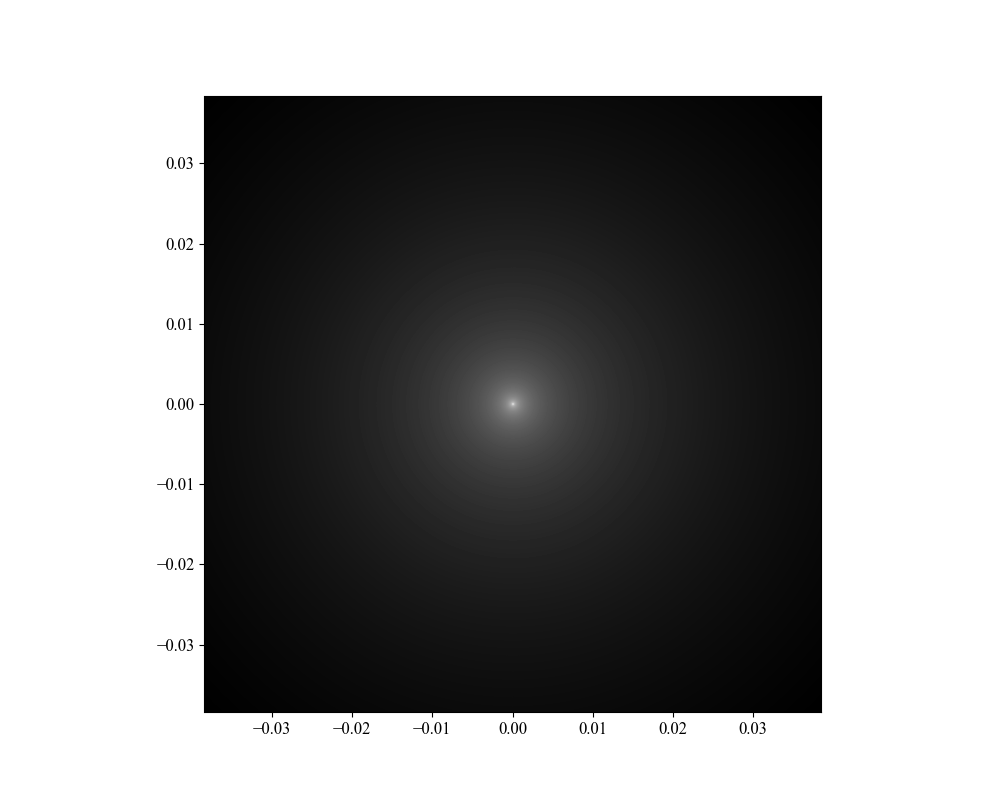

In [26]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

single_lens_counts = (single_lens.magnifications * sigma_ann) * old_A_pix  # Convert magnifications to counts
single_lens_magnifications = (single_lens_counts / A_pix) / sigma_ann

single_lens_uncertainty = single_lens_magnifications * 0.001

highres_image = zoom(single_lens_magnifications, scale_factor, order=1)  # bilinear interpolation
highres_uncertainty = zoom(single_lens_uncertainty, scale_factor, order=1)  # bilinear interpolation
print(highres_image.shape)

ax.imshow(np.log10(highres_image), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])

plt.show()

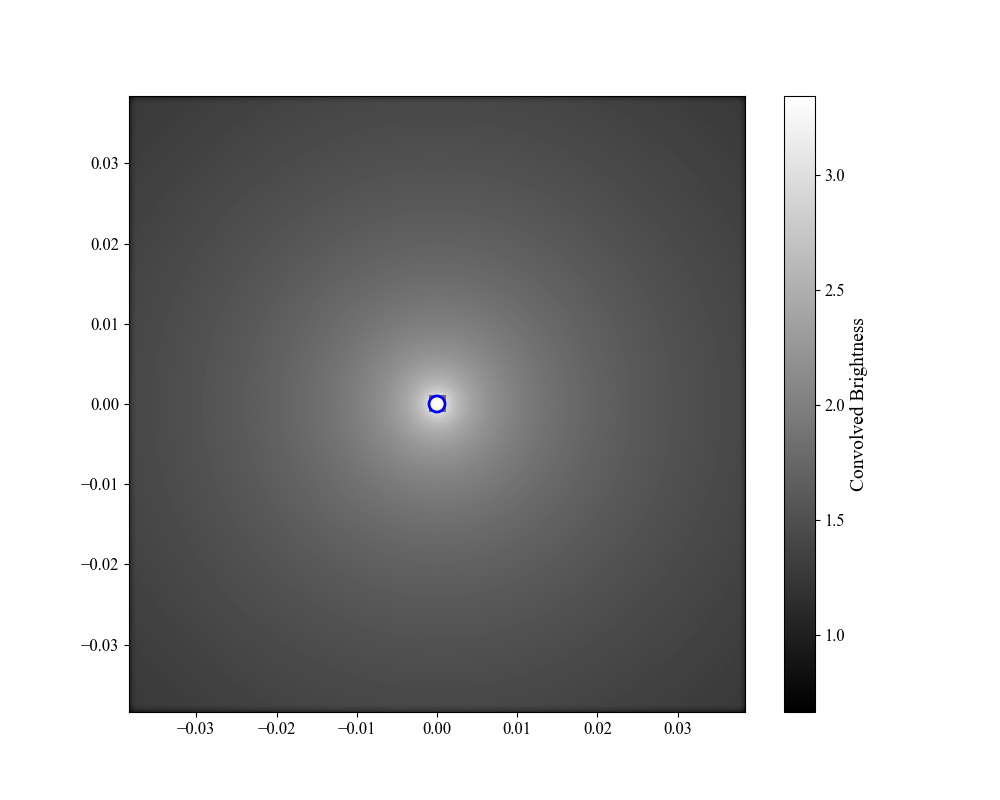

In [27]:
# convolved_brightnesses = binary_lens.convolve(source_profile)
highres_convolved_brightnesses = oaconvolve(highres_image, source_profile, mode='same')

# convolved_brightnesses = zoom(highres_convolved_brightnesses, 1/scale_factor, order=1)  # bilinear interpolation
convolved_brightnesses = highres_convolved_brightnesses

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()
img = ax.imshow(np.log10(convolved_brightnesses), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])
plt.colorbar(img, ax=ax, label='Convolved Brightness')

# print(np.max(convolved_brightnesses), np.min(convolved_brightnesses))
# print(np.sum(convolved_brightnesses))

source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
ax.add_patch(source_patch)
ax.imshow(source_profile, cmap='afmhot', extent=[-radius - new_ang_res / 2, radius + new_ang_res / 2, -radius - new_ang_res / 2, radius + new_ang_res / 2], alpha=0.5)

ax.set_xlim(-ang_width/2 - new_ang_res / 2, ang_width/2 + new_ang_res / 2)
ax.set_ylim(-ang_width/2 - new_ang_res / 2, ang_width/2 + new_ang_res / 2)

plt.show()

In [28]:
u = 0.005
alpha = 0

intersections, (numerical_xs, numerical_ys), (x_idx, y_idx), numerical_times, numerical_brightnesses = lightcurve_calculator(u=u, alpha=alpha, ang_width=ang_width, map_array=convolved_brightnesses)
intersections, (numerical_xs, numerical_ys), (x_idx, y_idx), numerical_times, numerical_uncertainties = lightcurve_calculator(u=u, alpha=alpha, ang_width=ang_width, map_array=highres_uncertainty)
intersections, (numerical_xs, numerical_ys), (x_idx, y_idx), numerical_times, numerical_magnifications = lightcurve_calculator(u=u, alpha=alpha, ang_width=ang_width, map_array=highres_image)

print(numerical_times.shape)
print(numerical_brightnesses.shape)

mm_param_dict = {'t_0': 0, 't_E': 1, 'u_0': u, 'rho': radius}
# mm_param_dict = {'t_0': -0.00001, 't_E': 1.00437, 'u_0': 0.00797, 'rho': 1.02207e-03}

single_model = mm.Model(mm_param_dict)

single_model.default_magnification_method = 'finite_source_LD_Yoo04'

mm_brightnesses = single_model.get_magnification(numerical_times, gamma=LD)
mm_trajectory = single_model.get_trajectory(numerical_times)

/var/folders/39/mb5cwg0x4h18n1y377g5rs9c0000gn/T/ipykernel_7707/974246826.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  t = (y_edge - y0) / dy


(10000,)
(10000,)


In [29]:
single_model.get_magnification(0, gamma=LD)


array([200.91478401])

0.0


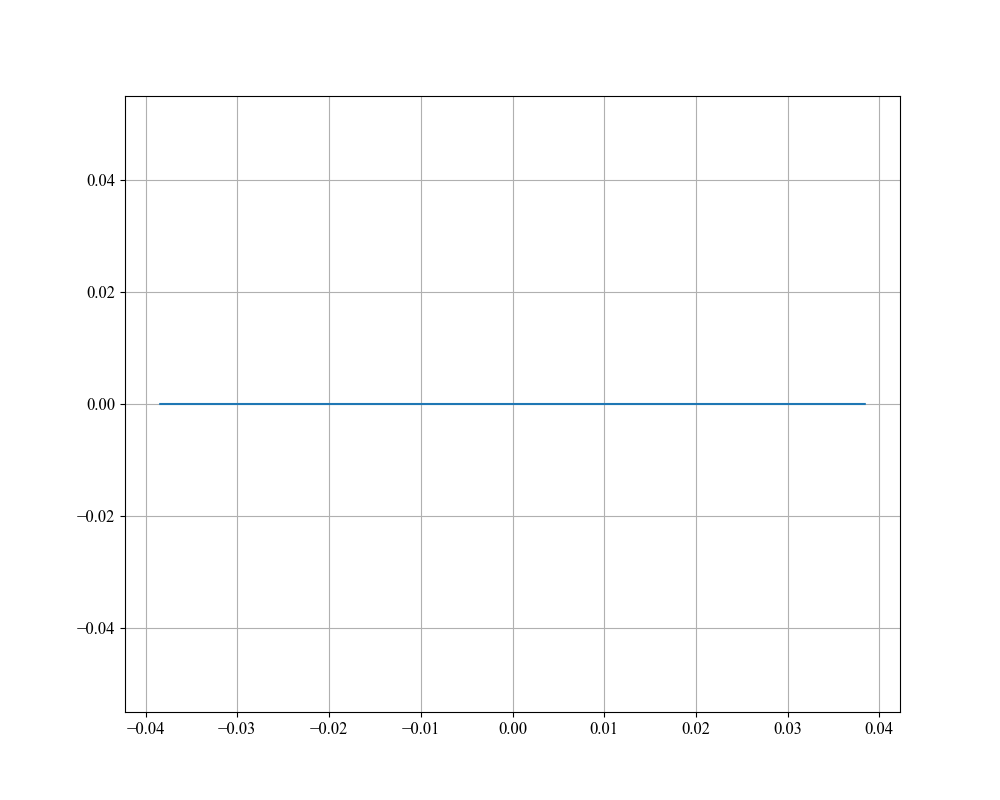

In [30]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

mm_xs = mm_trajectory.x
mm_ys = mm_trajectory.y

diff = (numerical_xs - mm_xs) / mm_xs

# ax.plot(numerical_times, numerical_xs, color='orange', label='Numerical X', linewidth=2)
# ax.plot(numerical_times, mm_xs, color='red', label='MulensModel X', linewidth=2)
ax.plot(numerical_times, diff)

print(np.max(np.abs(diff)))

ax.grid()

plt.show()

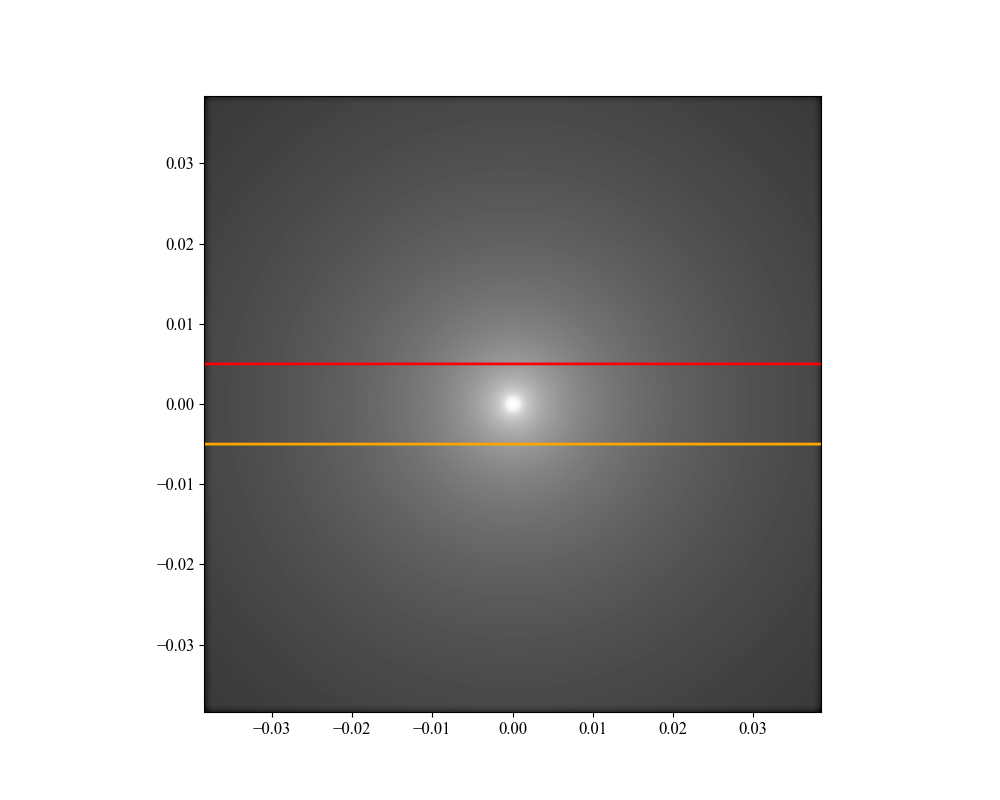

In [31]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.imshow(np.log10(convolved_brightnesses), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])
ax.plot(numerical_xs, numerical_ys, color='orange', label='Numerical Trajectory', linewidth=2)
ax.plot(mm_trajectory.x, mm_trajectory.y, color='red', label='MulensModel Trajectory', linewidth=2)

plt.show()

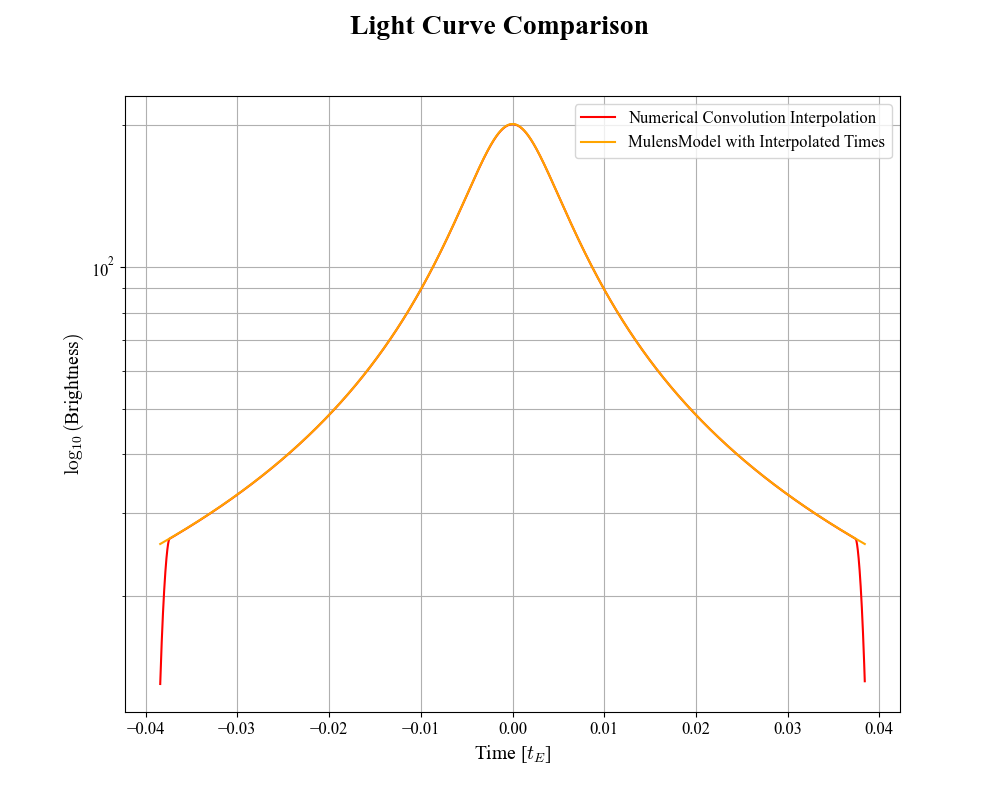

In [32]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Light Curve Comparison')

ax.semilogy(numerical_times, numerical_brightnesses, label='Numerical Convolution Interpolation', color='red')
ax.semilogy(numerical_times, mm_brightnesses, label='MulensModel with Interpolated Times', color='orange')

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('$\log_{10}($Brightness$)$')

ax.grid(True, 'both')
ax.legend()

plt.show()

0.0012750601030205172


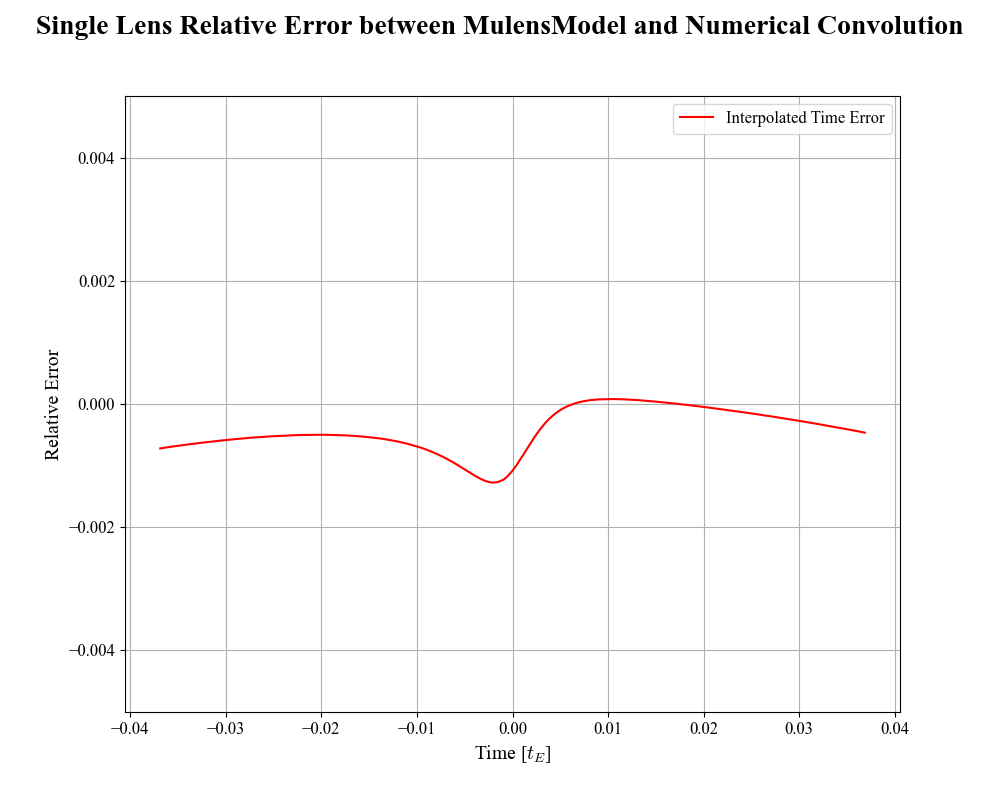

In [34]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Single Lens Relative Error between MulensModel and Numerical Convolution')

fractional_difference = (numerical_brightnesses - mm_brightnesses) / mm_brightnesses

ax.plot(numerical_times[200:9800], fractional_difference[200:9800], label='Interpolated Time Error', color='red')

print(np.nanmax(np.abs(fractional_difference[200:9800])))

ax.grid()
ax.legend()
# ax.set_xlim(-0.03, 0.03)
ax.set_ylim(-0.005, 0.005)

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('Relative Error')

plt.show()

#### Light curve fitting with MulensModel

In [667]:
import scipy.optimize as opt

def chi2_for_model(theta, event: mm.Event, parameters_to_fit: list):
    """
    for given event set attributes from parameters_to_fit
    (list of str) to values from the theta list
    """
    for (key, parameter) in enumerate(parameters_to_fit):
        setattr(event.model.parameters, parameter, theta[key])
    return event.get_chi2()

data = [
    numerical_times[200:9800],
    numerical_brightnesses[200:9800],
    numerical_uncertainties[200:9800]
]

print(np.shape(data))

(3, 9600)


Initial Chi2: 956.3525775279356


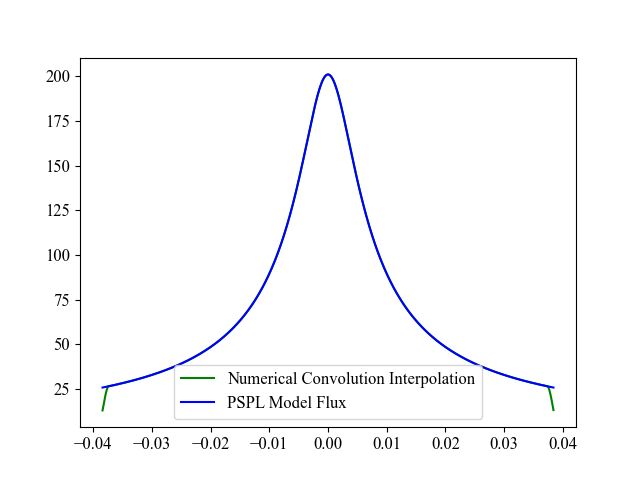

In [697]:
parameters_to_fit = ['t_0', 't_E', 'u_0', 'rho']
initial_guess = [0-0.0001, 1+0.0001, u+0.0001, radius+0.0001]
actual_params = [0, 1, u, radius]

pspl_model = mm.Model({'t_0': 0, 't_E': 1, 'u_0': u, 'rho': radius})
pspl_model.default_magnification_method = 'finite_source_LD_Yoo04'
pspl_model.set_limb_coeff_gamma("H", 0.5)

my_data = mm.MulensData(
    data_list=data,
    plot_properties={'color': 'thistle', 'label': "Sai's data", 'marker': '.', 'markersize': 0.5, 'alpha': 0.5},
    phot_fmt='flux',
    chi2_fmt='flux',
    bandpass='H'
)

my_event = mm.Event(datasets=my_data, model=pspl_model)
initial_chi2 = chi2_for_model(
    theta=[0, 1, u, radius],
    event=my_event,
    parameters_to_fit=parameters_to_fit
)

print(f'Initial Chi2: {initial_chi2}')

# my_event.plot_data()
pspl_model_mag = my_event.model.get_lc(times=numerical_times, source_flux=1, blend_flux=0)
pspl_model_flux = mm.Utils.get_flux_from_mag(pspl_model_mag)

plt.plot(numerical_times, numerical_brightnesses, label='Numerical Convolution Interpolation', color='green')
plt.plot(numerical_times, pspl_model_flux, label='PSPL Model Flux', color='blue')

plt.legend()
plt.show()

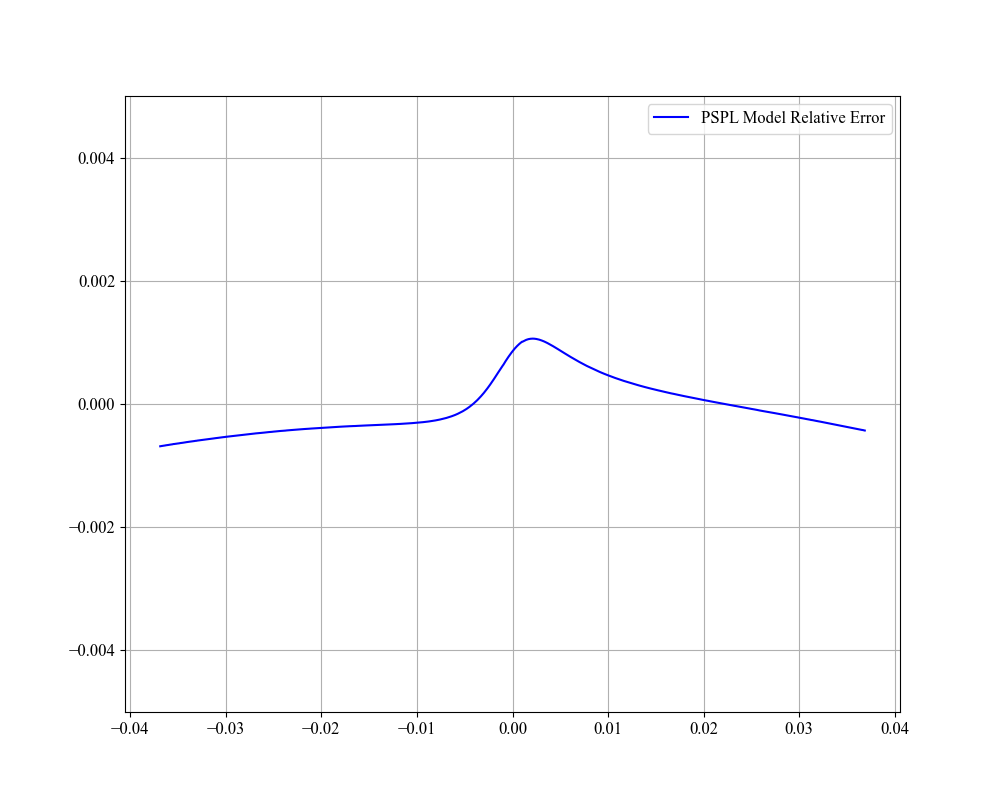

In [698]:
pspl_model_mags = pspl_model.get_magnification(numerical_times, gamma=LD)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

model_err = (numerical_brightnesses - pspl_model_mags) / pspl_model_mags

# ax.semilogy(numerical_times, pspl_model_mags, label='PSPL Model Magnification', color='blue')
# ax.semilogy(numerical_times, numerical_brightnesses, label='Numerical Convolution Interpolation', color='green')

ax.plot(numerical_times[200:9800], model_err[200:9800], label='PSPL Model Relative Error', color='blue')
ax.set_ylim(-0.005, 0.005)

ax.grid()
ax.legend()

plt.show()

In [705]:
result = opt.minimize(chi2_for_model, initial_guess, args=(my_event, parameters_to_fit), method='Nelder-Mead', tol=1e-4, options={'maxfev': 2000})

print("Fitting was successful? {:}".format(result.success))
if not result.success:
    print(result.message)
print("Function evaluations: {:}".format(result.nfev))
if isinstance(result.fun, np.ndarray):
    if result.fun.ndim == 0:
        result_fun = float(result.fun)
    else:
        result_fun = result.fun[0]
else:
    result_fun = result.fun

print("The smallest function value: {}".format(result_fun))
# print("for parameters: {:.5e} {:.5f}".format(*result.x.tolist()))

print('\nParameter = fitted value (expected inputted value)')
print('--------------------------------------------------')
for result_param, param_name, actual_param in zip(result.x.tolist(), parameters_to_fit, actual_params):
    print(f"{param_name} = {result_param:.5f} (expected {actual_param:.3f})")

print(f'\nInitial chi2: {initial_chi2:.3f}')
print(f'Final chi2: {result_fun:.3f}')

Fitting was successful? True
Function evaluations: 1454
The smallest function value: 0.6892551912034648

Parameter = fitted value (expected inputted value)
--------------------------------------------------
t_0 = 0.00000 (expected 0.000)
t_E = 1.19638 (expected 1.000)
u_0 = 0.00421 (expected 0.005)
rho = 0.00143 (expected 0.001)

Initial chi2: 956.353
Final chi2: 0.689


In [700]:
dataset = my_event.datasets[0]
my_event.fit_fluxes()
([FS], FB) = my_event.get_flux_for_dataset(dataset)

In [701]:
print(FS)
print(FB)

0.8359300629234563
-0.014619919519341483


In [723]:
# new_model = mm.Model({'t_0': result.x[0], 't_E': result.x[1], 'u_0': result.x[2], 'rho': result.x[3]})
# new_model.default_magnification_method = 'finite_source_LD_Yoo04'

sourceflux = FS
blendflux = FB

new_model_mag = my_event.model.get_lc(times=numerical_times, source_flux=sourceflux, blend_flux=blendflux)
new_model_flux = mm.Utils.get_flux_from_mag(new_model_mag)

# new_mm_brightnesses = new_model.get_magnification(numerical_times, gamma=LD)

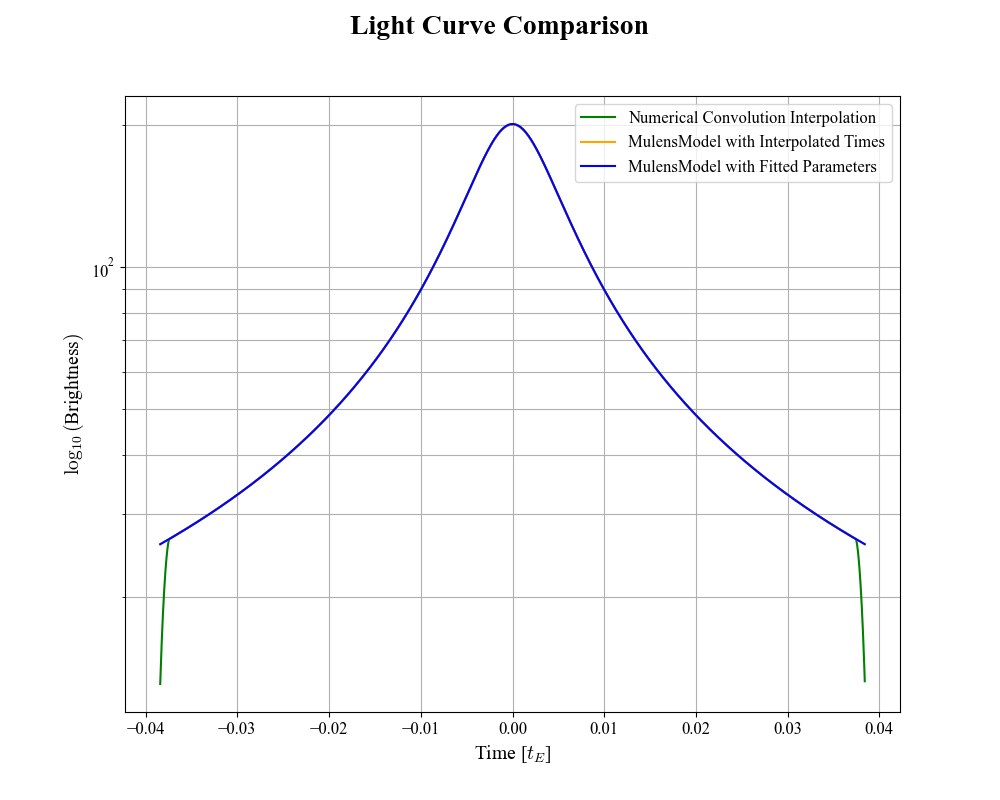

In [724]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Light Curve Comparison')

ax.semilogy(numerical_times, numerical_brightnesses, label='Numerical Convolution Interpolation', color='green')
ax.semilogy(numerical_times, mm_brightnesses, label='MulensModel with Interpolated Times', color='orange')
# ax.semilogy(numerical_times, new_mm_brightnesses, label='MulensModel with Fitted Parameters', color='blue')
ax.semilogy(numerical_times, new_model_flux, label='MulensModel with Fitted Parameters', color='blue')

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('$\log_{10}($Brightness$)$')

ax.grid(True, 'both')
ax.legend()

plt.show()

0.0010612595885896804
0.001550900528806332


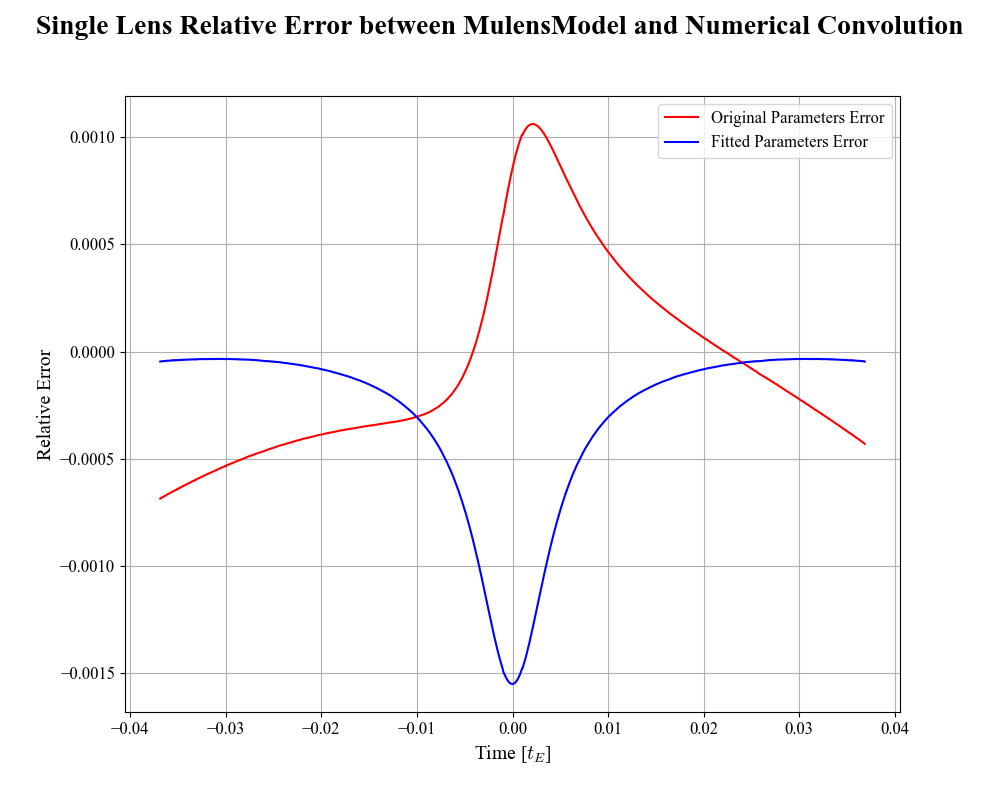

In [725]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Single Lens Relative Error between MulensModel and Numerical Convolution')

fractional_difference = (numerical_brightnesses - mm_brightnesses) / mm_brightnesses
new_fractional_difference = (numerical_brightnesses - new_model_flux) / new_model_flux

ax.plot(numerical_times[200:9800], fractional_difference[200:9800], label='Original Parameters Error', color='red')
ax.plot(numerical_times[200:9800], new_fractional_difference[200:9800], label='Fitted Parameters Error', color='blue')

print(np.nanmax(np.abs(fractional_difference[200:9800])))
print(np.nanmax(np.abs(new_fractional_difference[200:9800])))

ax.grid()
ax.legend()
# ax.set_xlim(-0.03, 0.03)
# ax.set_ylim(-0.005, 0.005)

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('Relative Error')

plt.show()

#### Binary testing

(8000, 8000)


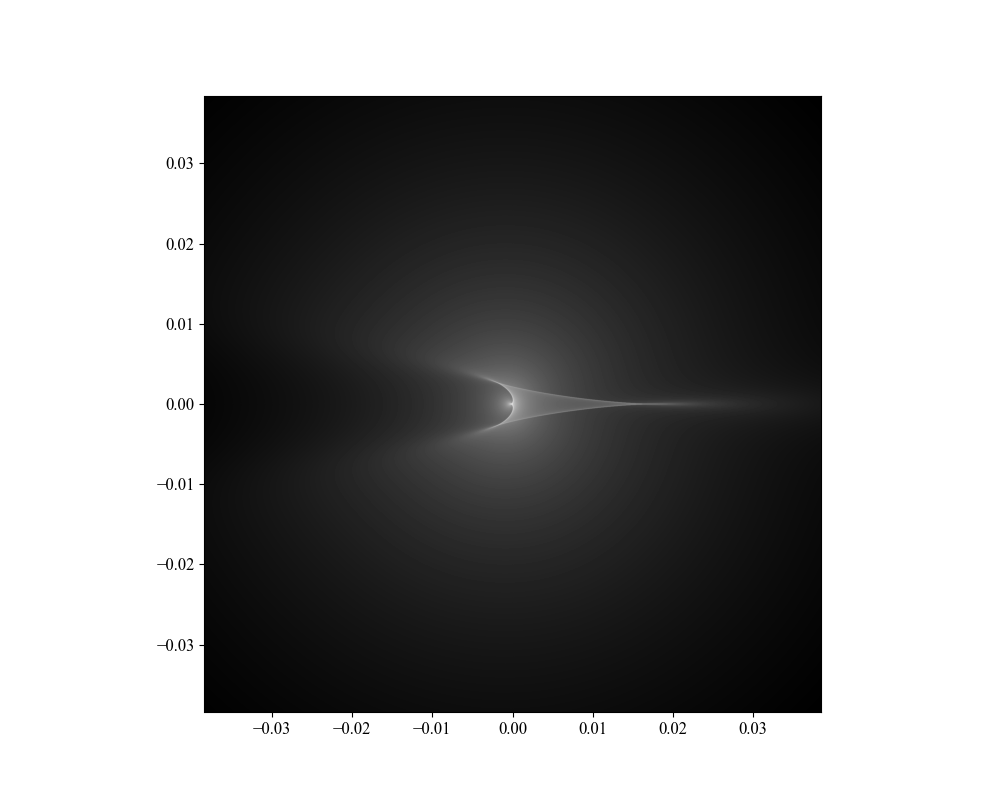

In [726]:
# binary_lens.plot()
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

binary_lens_counts = (binary_lens.magnifications * sigma_ann) * old_A_pix  # Convert magnifications to counts
binary_lens_magnifications = (binary_lens_counts / A_pix) / sigma_ann

binary_lens_uncertainty = binary_lens_magnifications * 0.001

highres_image = zoom(binary_lens_magnifications, scale_factor, order=1)  # bilinear interpolation
highres_uncertainty = zoom(binary_lens_uncertainty, scale_factor, order=1)  # bilinear interpolation
print(highres_image.shape)

ax.imshow(np.log10(highres_image), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])

plt.show()

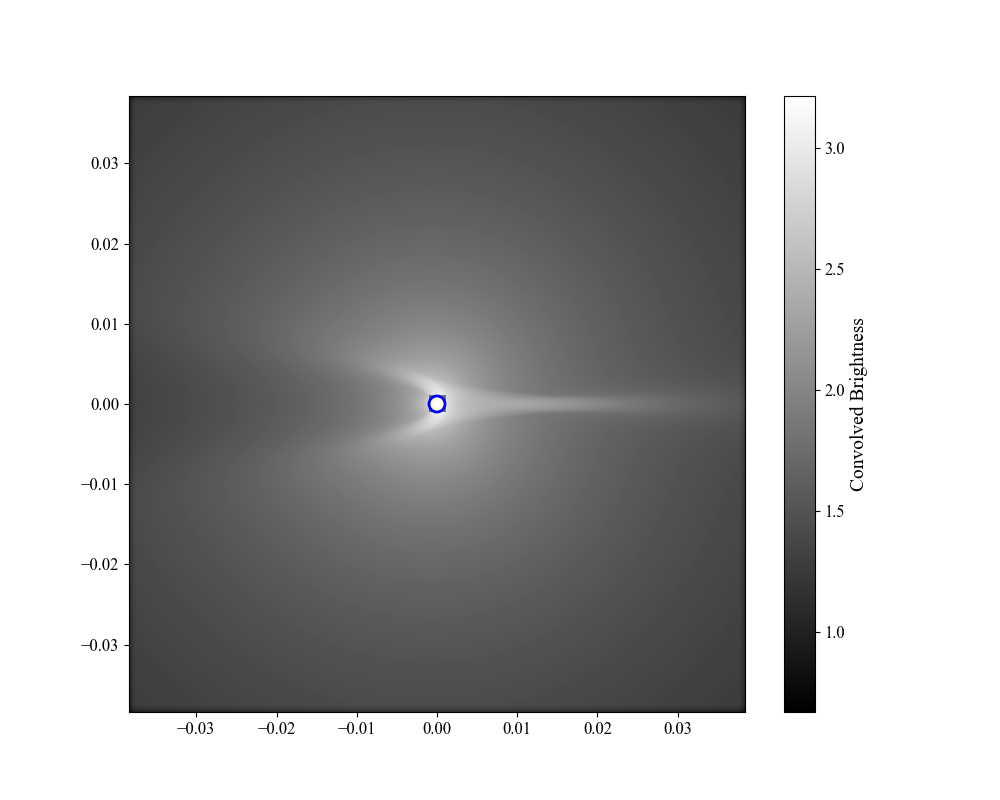

In [727]:
# convolved_brightnesses = binary_lens.convolve(source_profile)
highres_convolved_brightnesses = oaconvolve(highres_image, source_profile, mode='same')

# convolved_brightnesses = zoom(highres_convolved_brightnesses, 1/scale_factor, order=1)  # bilinear interpolation
convolved_brightnesses = highres_convolved_brightnesses

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()
img = ax.imshow(np.log10(convolved_brightnesses), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])
plt.colorbar(img, ax=ax, label='Convolved Brightness')

# print(np.max(convolved_brightnesses), np.min(convolved_brightnesses))
# print(np.sum(convolved_brightnesses))

source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
ax.add_patch(source_patch)
ax.imshow(source_profile, cmap='afmhot', extent=[-radius - new_ang_res / 2, radius + new_ang_res / 2, -radius - new_ang_res / 2, radius + new_ang_res / 2], alpha=0.5)

ax.set_xlim(-ang_width/2 - new_ang_res / 2, ang_width/2 + new_ang_res / 2)
ax.set_ylim(-ang_width/2 - new_ang_res / 2, ang_width/2 + new_ang_res / 2)

plt.show()

In [739]:
u = 0.008
alpha = 30

# intersections, (numerical_xs, numerical_ys), numerical_times, numerical_brightnesses = IRSC.IRSCaustics.lightcurve_calculator(u=u, alpha=alpha, ang_width=ang_width, lens_CM=lens_CM, offset=delta1, map_array=convolved_brightnesses)
intersections, (numerical_xs, numerical_ys), (x0, y0), numerical_times, numerical_brightnesses = lightcurve_calculator(u=u, alpha=alpha, ang_width=ang_width, lens_CM=lens_CM, offset=delta1, map_array=convolved_brightnesses)

print(numerical_times.shape)
print(numerical_brightnesses.shape)

mm_param_dict = {'t_0': 0, 't_E': 1, 'u_0': u, 'rho': radius, 'q': 1e-3, 'alpha': alpha, 's': 0.8}
binary_model = mm.Model(mm_param_dict)

binary_model.default_magnification_method = 'VBBL'

mm_brightnesses = binary_model.get_magnification(numerical_times, gamma=LD)
mm_trajectory = binary_model.get_trajectory(numerical_times)

(10000,)
(10000,)


0.08511508004190932


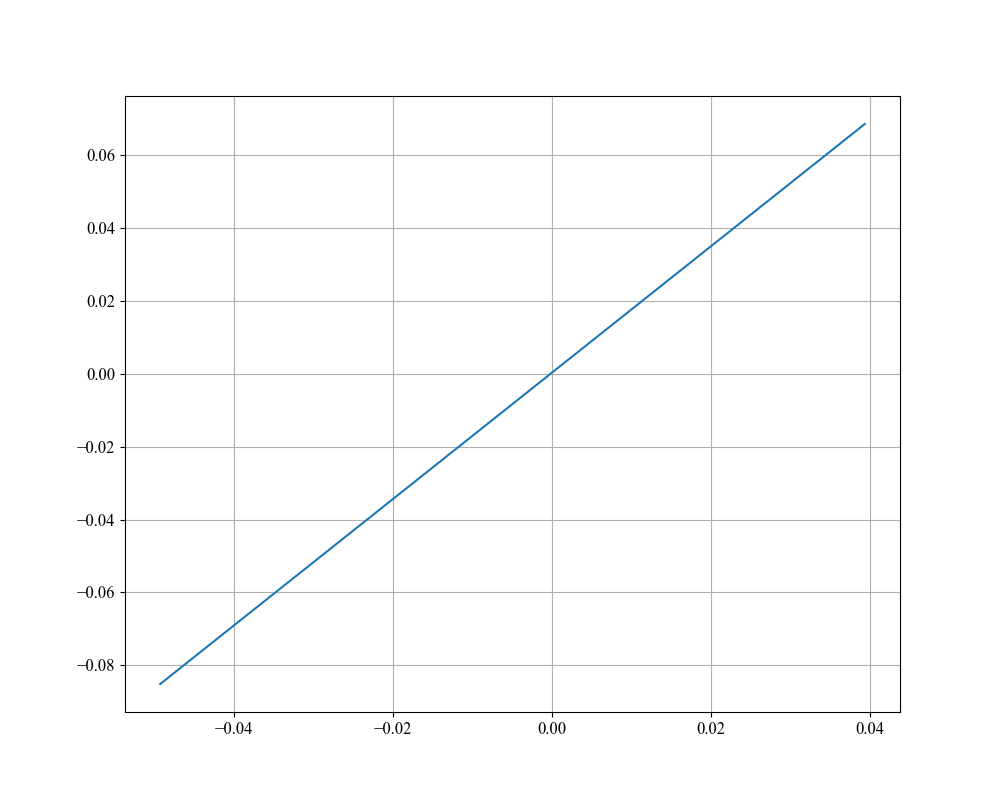

In [740]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

mm_xs = mm_trajectory.x
mm_ys = mm_trajectory.y

diff = (numerical_xs - mm_xs)

# ax.plot(numerical_times, numerical_xs, color='orange', label='Numerical X', linewidth=2)
# ax.plot(numerical_times, mm_xs, color='red', label='MulensModel X', linewidth=2)
ax.plot(numerical_times, diff)

print(np.max(np.abs(diff)))

ax.grid()

plt.show()

In [737]:
print(intersections)

t_1_x = (u*np.sin(np.deg2rad(alpha)) - intersections[0, 0]) / np.cos(np.deg2rad(alpha))
t_1_y = -(u*np.cos(np.deg2rad(alpha)) + intersections[0, 1]) / np.sin(np.deg2rad(alpha))

print(t_1_x, t_1_y)

[[-0.0384016  -0.01311363]
 [ 0.0384016   0.03122871]]
0.04896114850246649 0.012370863017983237


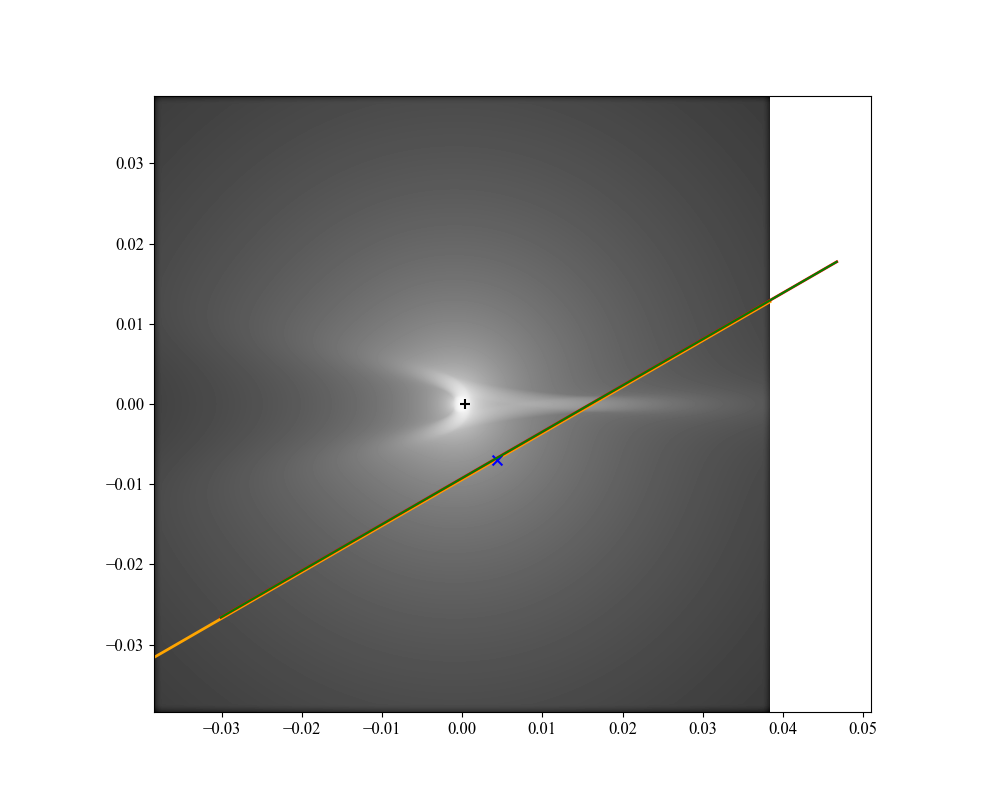

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.imshow(np.log10(convolved_brightnesses), cmap='grey', extent=[-ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2, -ang_width/2 - new_ang_res/2, ang_width/2 + new_ang_res/2])
ax.plot(numerical_xs, numerical_ys, color='orange', label='Numerical Trajectory', linewidth=2)
ax.plot(mm_trajectory.x, mm_trajectory.y, color='red', label='MulensModel Trajectory', linewidth=2)

ax.scatter(*(lens_CM - delta1), color='black', s=50, label='Lens Center of Mass', zorder=10, marker='+')
ax.scatter(x0, y0, color='blue', s=50, label='Trajectory Origin', zorder=10, marker='x')

x_traj = u*np.sin(np.deg2rad(alpha)) - numerical_times*np.cos(np.deg2rad(alpha))
y_traj = -u*np.cos(np.deg2rad(alpha)) - numerical_times*np.sin(np.deg2rad(alpha))

ax.plot(x_traj, y_traj, color='green', label='Impact Parameter', zorder=10)

plt.show()

In [297]:
np.hypot(*((lens_CM - delta1) - np.array([x0, y0])))
np.arctan2((lens_CM - delta1)[1] - y0, (lens_CM - delta1)[0] - x0) * 180 / np.pi

np.float64(120.00000000000001)

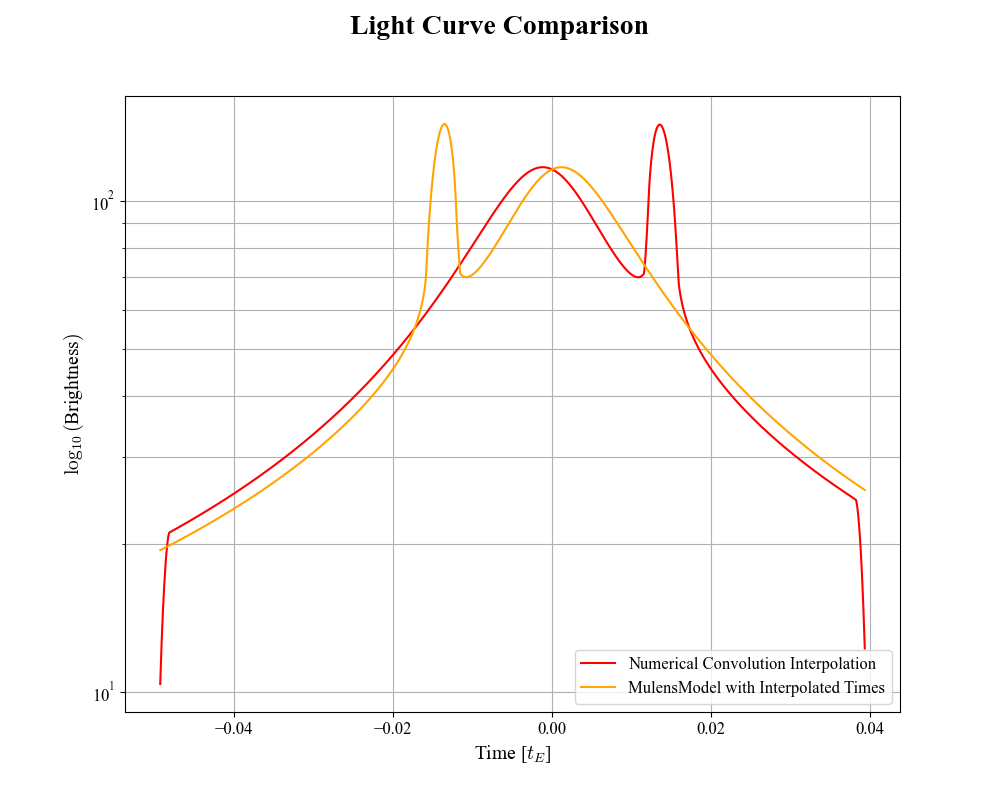

In [268]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Light Curve Comparison')

# ax.semilogy(numerical_times, numerical_brightnesses, label='Numerical Convolution', color='blue')
# ax.semilogy(numerical_times, mm_brightnesses, label='MulensModel with Pixel Times', color='green')
ax.semilogy(numerical_times, numerical_brightnesses, label='Numerical Convolution Interpolation', color='red')
ax.semilogy(numerical_times, mm_brightnesses, label='MulensModel with Interpolated Times', color='orange')

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('$\log_{10}($Brightness$)$')

ax.grid(True, 'both')
ax.legend()

plt.show()

0.25889097498075664


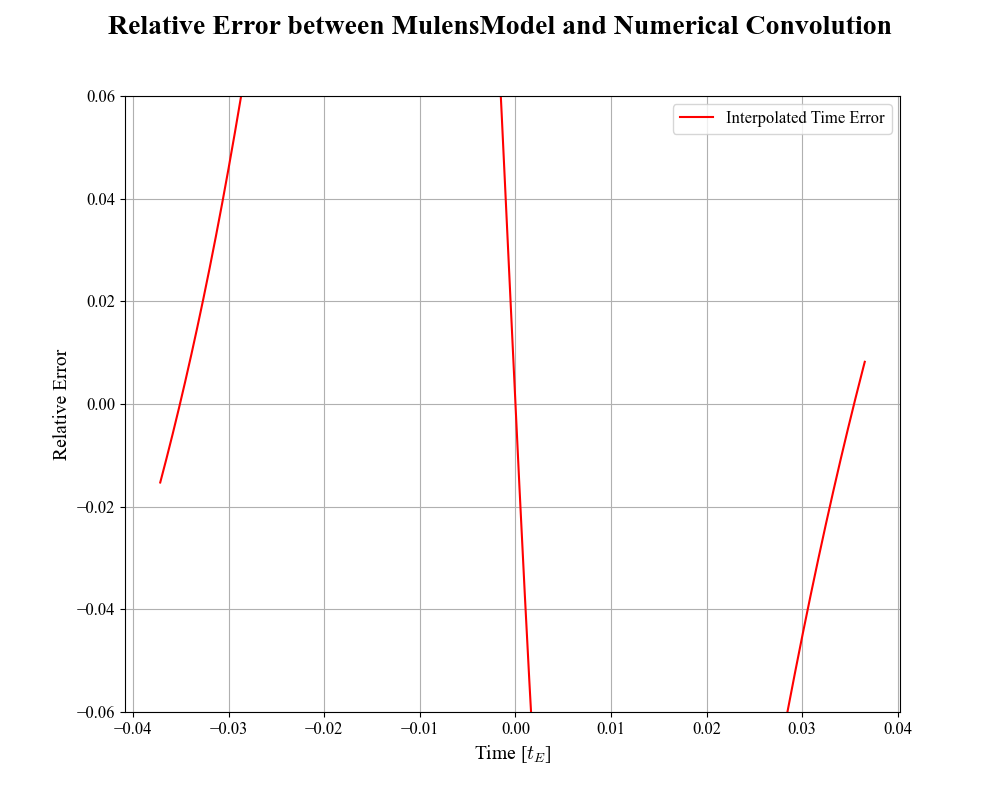

In [249]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

fig.suptitle('Relative Error between MulensModel and Numerical Convolution')

fractional_difference = (numerical_brightnesses - mm_brightnesses) / mm_brightnesses
# fractional_difference2 = (numerical2_brightnesses - mm2_brightnesses) / mm2_brightnesses

ax.plot(numerical_times[200:9800], fractional_difference[200:9800], label='Interpolated Time Error', color='red')

# print(np.nanmax(np.abs(fractional_difference[7000:9000])))
print(np.nanmax(np.abs(fractional_difference[200:9800])))

ax.grid()
ax.legend()
# ax.set_xlim(-0.004, 0.004)
ax.set_ylim(-0.06, 0.06)

ax.set_xlabel('Time [$t_E$]')
ax.set_ylabel('Relative Error')

plt.show()

In [242]:
import scipy.optimize as opt

def chi2_for_model(theta, event, parameters_to_fit):
    """
    for given event set attributes from parameters_to_fit
    (list of str) to values from the theta list
    """
    for (key, parameter) in enumerate(parameters_to_fit):
        setattr(event.model.parameters, parameter, theta[key])
    return event.get_chi2()

data = [
    numerical_times[200:9800],
    numerical_brightnesses[200:9800],
    numerical_uncertainties[200:9800]
]

print(np.shape(data))

(3, 9600)


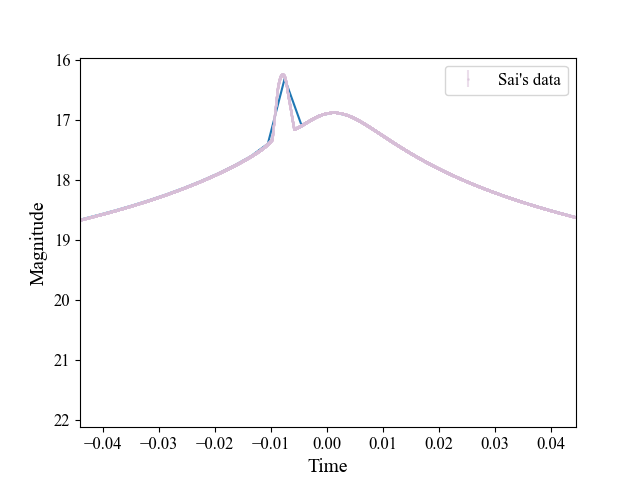

In [244]:
parameters_to_fit = ['t_0', 't_E', 'u_0', 'rho', 'q', 'alpha', 's']

binary_model = mm.Model({'t_0': 0, 't_E': 1, 'u_0': u, 'rho': radius, 'q': 1e-3, 'alpha': alpha, 's': 0.8})
binary_model.default_magnification_method = 'VBBL'
binary_model.set_limb_coeff_gamma("H", 0.5)

my_data = mm.MulensData(
    data_list=data,
    plot_properties={'color': 'thistle', 'label': "Sai's data", 'marker': '.', 'markersize': 2, 'alpha': 0.5},
    phot_fmt='flux',
    bandpass='H'
)
my_event = mm.Event(datasets=my_data, model=binary_model)

my_event.plot_data()
my_event.plot_model()

plt.legend()
plt.show()

#### Analytic convolution testing

In [408]:
# scale_factor = 2
image = binary_lens.magnifications
# image = zoom(image, scale_factor, order=1)  # bilinear interpolation
# ang_res /= scale_factor
# radius *= scale_factor

In [409]:
from scipy.special import j1, jv
import numpy as np

import numpy as np
from scipy.special import j1, jv

def limb_darkened_ft_analytic(k, R=1.0, Gamma=0.5):
    A = 1 - Gamma
    B = 1.5 * Gamma  # since Gamma * 3/2

    x = 2 * np.pi * k * R

    # Avoid division by zero — this will be patched later
    term1 = np.zeros_like(k)
    term2 = np.zeros_like(k)

    nonzero = k > 0

    # First term: uniform disk
    term1[nonzero] = A * R**2 * j1(x[nonzero]) / (k[nonzero] * R)

    # Second term: limb-darkened component
    J_3_2 = jv(1.5, x[nonzero])
    term2[nonzero] = (
        B * 2 * np.pi * R**3 *
        (np.sqrt(np.pi) / (x[nonzero])**1.5) *
        J_3_2
    )

    # Combine both terms
    ft = term1 + term2

    # Set DC (k=0) manually to total flux
    total_flux = np.pi * R**2 * (1 - Gamma / 3)
    ft[k == 0] = total_flux

    return ft

def analytic_convolve(image, radius, ang_res, LD=0.5):
    """
    Perform analytic convolution of an image with a limb-darkened circular source profile.
    
    Parameters:
    - image: 2D numpy array representing the image to be convolved.
    - radius: Radius of the source in angular units.
    - ang_res: Angular resolution of the image.
    - LD: Limb darkening coefficient (default is 0.5).
    
    Returns:
    - convolved_image: 2D numpy array of the convolved image.
    """
    pad_pixels = int(np.ceil(2 * radius / ang_res))  # support diameter in pixels
    image_padded = np.pad(image, pad_pixels, mode='constant', constant_values=0)
    
    # Compute FFT
    fft_image_padded = np.fft.fft2(image_padded)

    ny, nx = image_padded.shape
    kx = np.fft.fftfreq(nx, d=ang_res)
    ky = np.fft.fftfreq(ny, d=ang_res)
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    pixel_window = np.sinc(KX * ang_res) * np.sinc(KY * ang_res)  # Pixel window function

    ft_kernel = limb_darkened_ft_analytic(K, R=radius, Gamma=LD)

    # Apply a phase shift to analytically shift the center
    x_shift = -0.5 * ang_res  # or whatever offset you need
    phase = np.exp(-2j * np.pi * (KX * x_shift + KY * x_shift))

    ft_kernel *= pixel_window  # Apply pixel window function
    ft_kernel = ft_kernel.astype(np.complex128)  # Ensure complex type for FFT operations
    ft_kernel *= phase  # Apply phase shift
    ft_kernel /= ft_kernel[0, 0]  # Normalize the kernel

    convolved_analytic_padded = np.fft.ifft2(fft_image_padded * ft_kernel).real

    convolved_analytic = convolved_analytic_padded[pad_pixels:-pad_pixels, pad_pixels:-pad_pixels]

    return convolved_analytic, ft_kernel

0.5384640933797964


/var/folders/39/mb5cwg0x4h18n1y377g5rs9c0000gn/T/ipykernel_9815/1088928387.py:23: RuntimeWarning: divide by zero encountered in divide
  img = ax.imshow((analytic_convolved_impulse - numeric_convolved_impulse) / numeric_convolved_impulse, cmap='grey', extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2], vmin=-0.1, vmax=0.1)


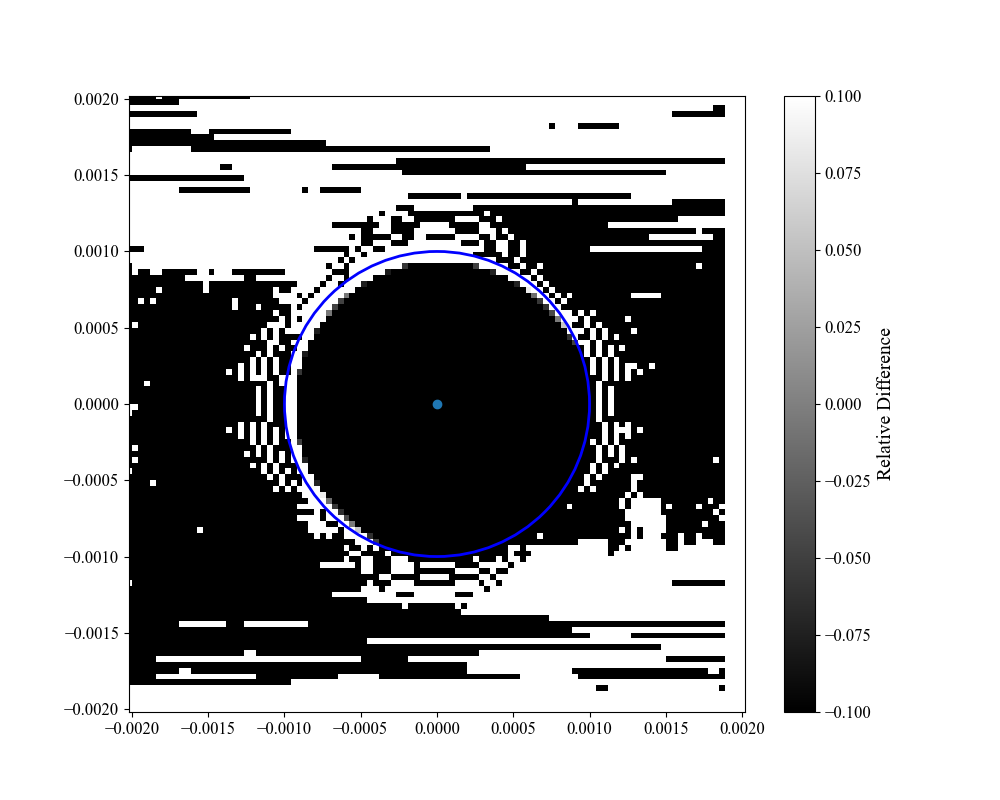

In [410]:
# Create an impulse image (4 bright pixel)
ny, nx = image.shape
impulse = np.zeros((ny, nx), dtype=np.float64)

cy, cx = ny // 2, nx // 2
impulse[cy - 1, cx - 1] = 0.25
impulse[cy - 1, cx    ] = 0.25
impulse[cy    , cx - 1] = 0.25
impulse[cy    , cx    ] = 0.25

analytic_convolved_impulse, analytic_source_kernel = analytic_convolve(impulse, radius, ang_res, LD=LD)
numeric_convolved_impulse = oaconvolve(impulse, source_profile, mode='same')

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()
# ax.imshow(numeric_convolved_impulse, cmap='viridis', extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2])
# ax.imshow(analytic_convolved_impulse, cmap='grey', extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2], alpha=0.5)
# ax.imshow(impulse, cmap='hot', extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2], alpha=0.5)
ax.scatter(0, 0)
source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
ax.add_patch(source_patch)

img = ax.imshow((analytic_convolved_impulse - numeric_convolved_impulse) / numeric_convolved_impulse, cmap='grey', extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2], vmin=-0.1, vmax=0.1)
print(np.max(np.abs(analytic_convolved_impulse - numeric_convolved_impulse)) / np.max(numeric_convolved_impulse))

plt.colorbar(img, ax=ax, label='Relative Difference')

ax.set_xlim(-2 * radius - ang_res / 2, 2 * radius + ang_res / 2)
ax.set_ylim(-2 * radius - ang_res / 2, 2 * radius + ang_res / 2)

plt.show()

In [411]:
print(source_profile.shape)

(52, 52)


(2000, 2000)
(52, 52)


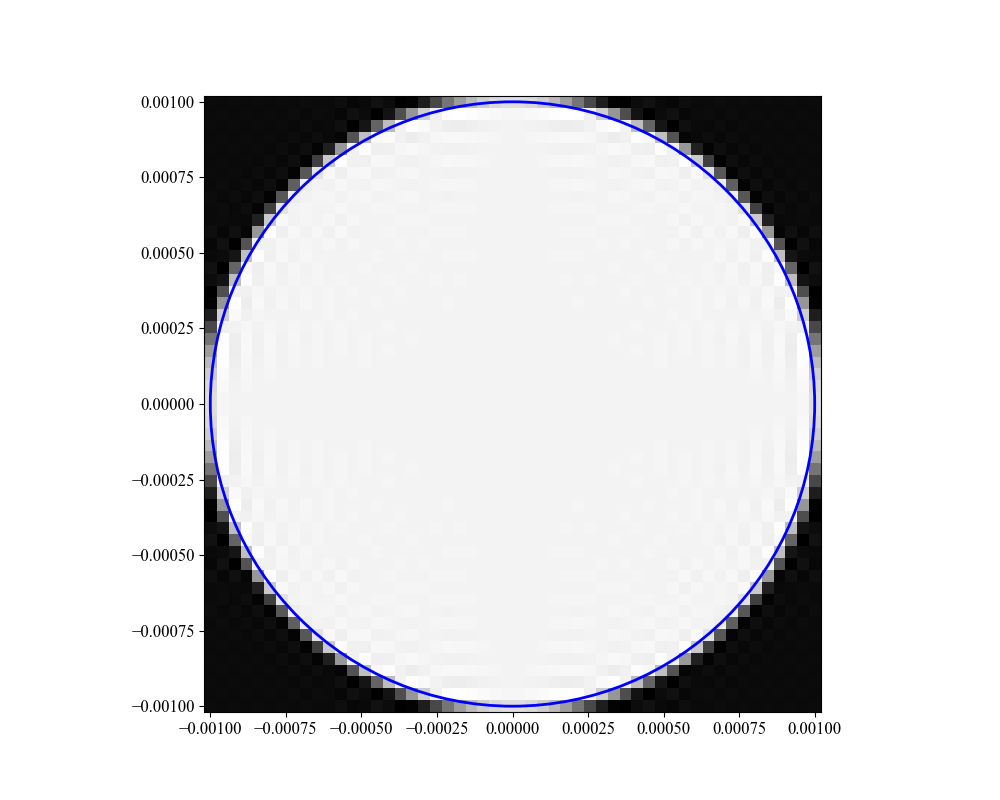

In [421]:
pad_pixels = int(np.ceil(2 * radius / ang_res))  # support diameter in pixels

analytic_source_profile = np.fft.fftshift(np.fft.ifft2(analytic_source_kernel).real)[pad_pixels:-pad_pixels, pad_pixels:-pad_pixels]

cropped_analytic_source_profile = analytic_source_profile[1000 - 26: 1000 + 26, 1000 - 26: 1000 + 26]
print(analytic_source_profile.shape)
print(cropped_analytic_source_profile.shape)

# cropped_analytic_source_profile /= np.sum(cropped_analytic_source_profile)  # Normalize the analytic source profile

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()
# ax.imshow(analytic_source_profile, cmap='afmhot', extent=[-ang_width/2 - ang_res / 2, ang_width/2 + ang_res / 2, -ang_width/2 - ang_res / 2, ang_width/2 + ang_res / 2])
ax.imshow(cropped_analytic_source_profile, cmap='grey', extent=[-radius - ang_res / 2, radius + ang_res / 2, -radius - ang_res / 2, radius + ang_res / 2])
# ax.imshow(source_profile, cmap='viridis', extent=[-radius - ang_res / 2, radius + ang_res / 2, -radius - ang_res / 2, radius + ang_res / 2], alpha=0.5)
# plt.colorbar(img, ax=ax, label='Source Brightness')

# img = ax.imshow((cropped_analytic_source_profile - source_profile) / source_profile, cmap='grey', extent=[-radius - ang_res / 2, radius + ang_res / 2, -radius - ang_res / 2, radius + ang_res / 2], vmin=-0.1, vmax=0.1)
# plt.colorbar(img, ax=ax, label='Relative Difference')

ax.set_xlim(-radius - ang_res / 2, radius + ang_res / 2)
ax.set_ylim(-radius - ang_res / 2, radius + ang_res / 2)

# ax.imshow(analytic_source_profile, cmap='afmhot')

# ax.set_xlim(1000 - 100, 1000 + 100)
# ax.set_ylim(1000 - 100, 1000 + 100)

source_patch = patches.Circle((0, 0), radius, color='blue', alpha=1, label='Source', zorder=10, fill=False, linewidth=2)
ax.add_patch(source_patch)

plt.show()

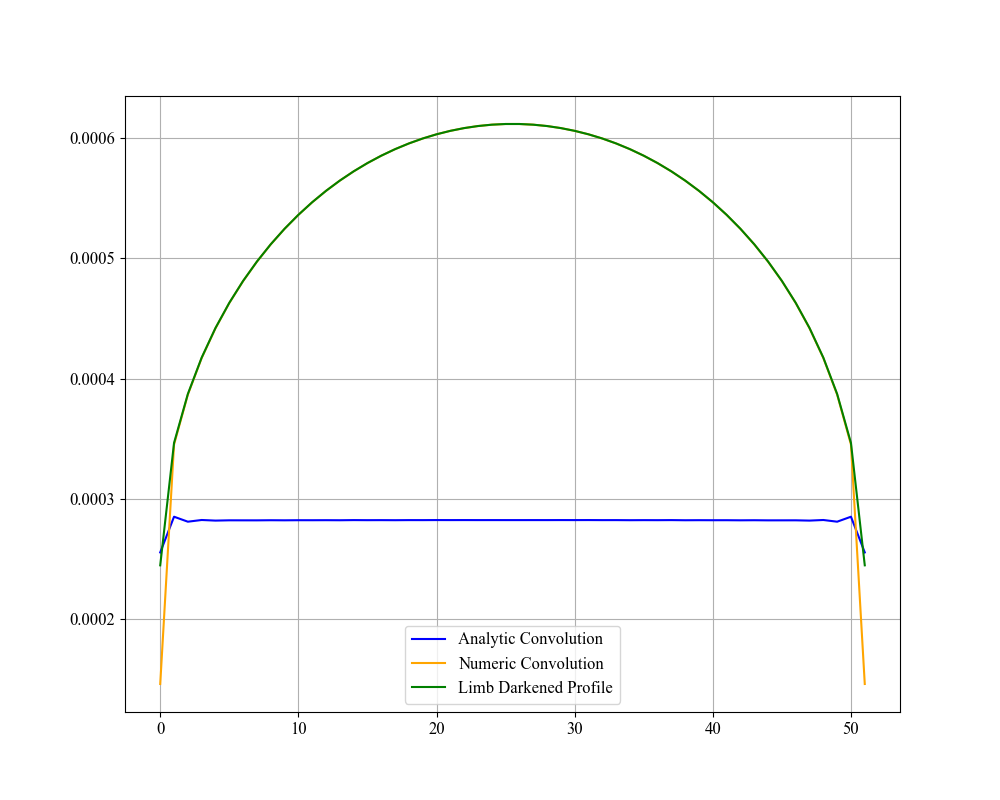

In [439]:
analytic_slice = cropped_analytic_source_profile[26, :]
numeric_slice = source_profile[26, :]

def ld_profile_r(r, R=1.0, Gamma=0.5):
    mu = np.sqrt(1 - (r / R)**2)
    mu = np.clip(mu, 0, 1)
    return 1 - Gamma * (1 - 1.5 * mu)

rs = np.linspace(-radius, radius, 52)
ld_profile = ld_profile_r(rs, R=radius, Gamma=LD)
ld_profile = ld_profile / np.max(ld_profile) * np.max(source_profile)  # Normalize the limb darkened profile

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()
ax.plot(analytic_slice, label='Analytic Convolution', color='blue')
ax.plot(numeric_slice, label='Numeric Convolution', color='orange')
ax.plot(ld_profile, label='Limb Darkened Profile', color='green')

ax.grid()
ax.legend()

# ax.set_ylim(0.000275, 0.000285)

plt.show()

943.6273621926176 19.427698933365164
175906164.01068026
(2000, 2000)


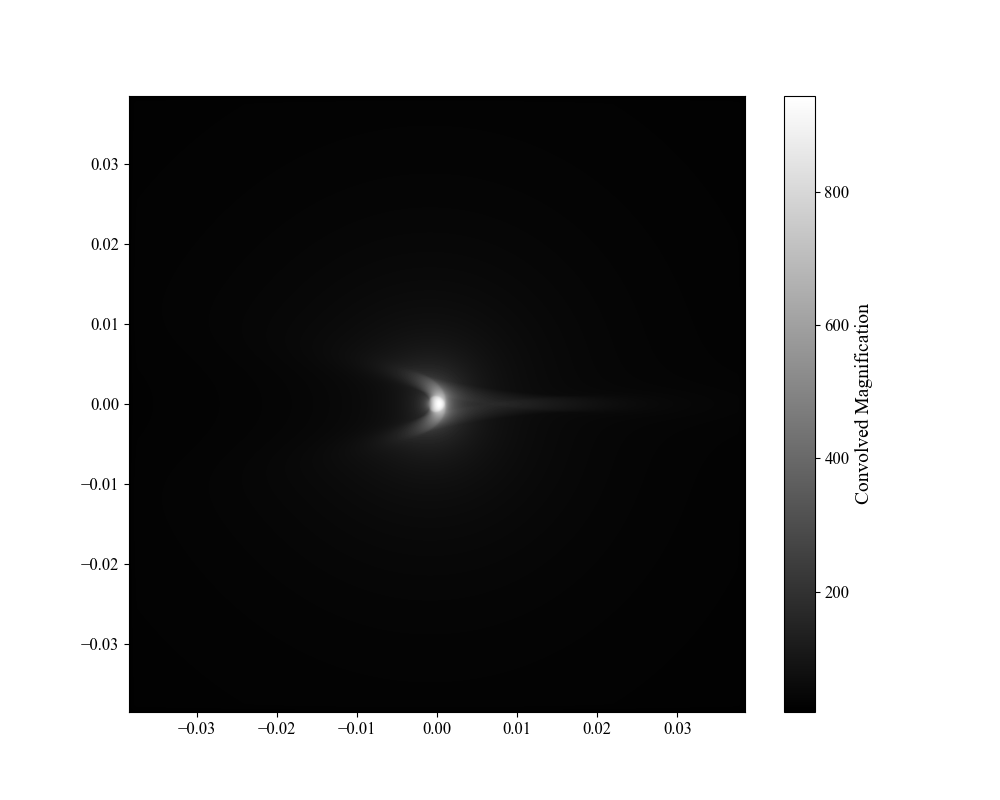

In [304]:
convolved_analytic = analytic_convolve(image, radius, ang_res, LD=LD)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

img = ax.imshow(convolved_analytic, cmap='grey', extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2])
plt.colorbar(img, ax=ax, label='Convolved Magnification')

print(np.max(convolved_analytic), np.min(convolved_analytic))
print(np.sum(convolved_analytic))
print(convolved_analytic.shape)

plt.show()

In [462]:
u = 0.003
alpha = 45

intersections, (numerical_xs, numerical_ys), numerical_times, numerical_brightnesses = IRSC.IRSCaustics.lightcurve_calculator(u=u, alpha=alpha, ang_width=ang_width, map_array=convolved_brightnesses)
intersections, (analytic_xs, analytic_ys), analytic_times, analytic_brightnesses = IRSC.IRSCaustics.lightcurve_calculator(u=u, alpha=alpha, ang_width=ang_width, map_array=convolved_analytic)

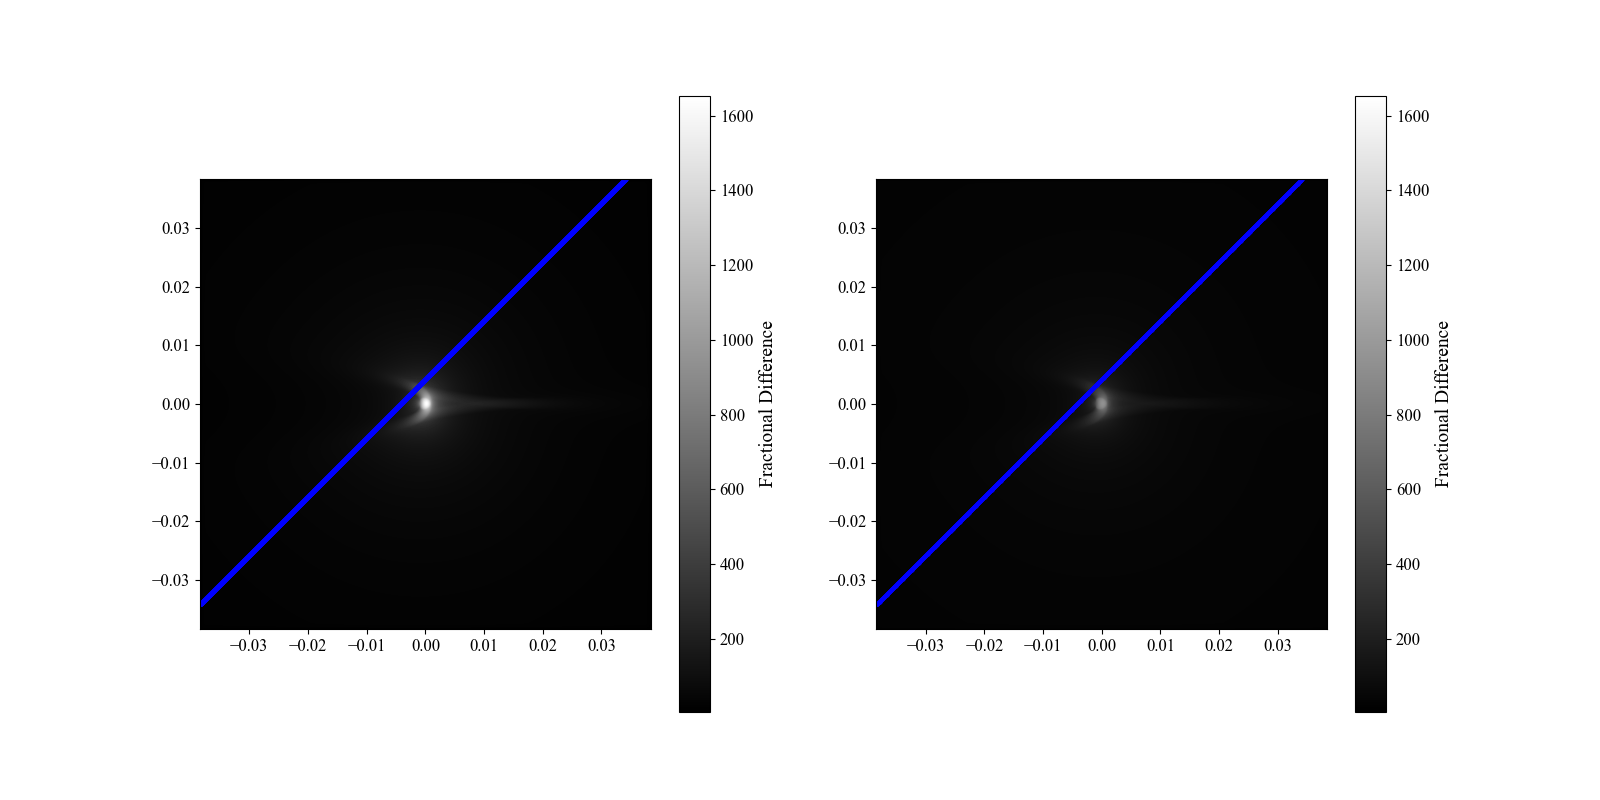

In [463]:
fig = plt.figure(figsize=(16, 8))
axes = fig.subplots(1, 2)

img1 = axes[0].imshow(convolved_brightnesses, cmap='grey', extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2], vmin=np.min(convolved_brightnesses), vmax=np.max(convolved_brightnesses))
img2 = axes[1].imshow(convolved_analytic, cmap='grey', extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2], vmin=np.min(convolved_brightnesses), vmax=np.max(convolved_brightnesses))

axes[0].plot(numerical_xs, numerical_ys, 'o', color='blue', markersize=2)
axes[1].plot(analytic_xs, analytic_ys, 'o', color='blue', markersize=2)

bar1 = fig.colorbar(img1, ax=axes[0])
bar1.set_label('Fractional Difference')

bar2 = fig.colorbar(img2, ax=axes[1])
bar2.set_label('Fractional Difference')

plt.show()

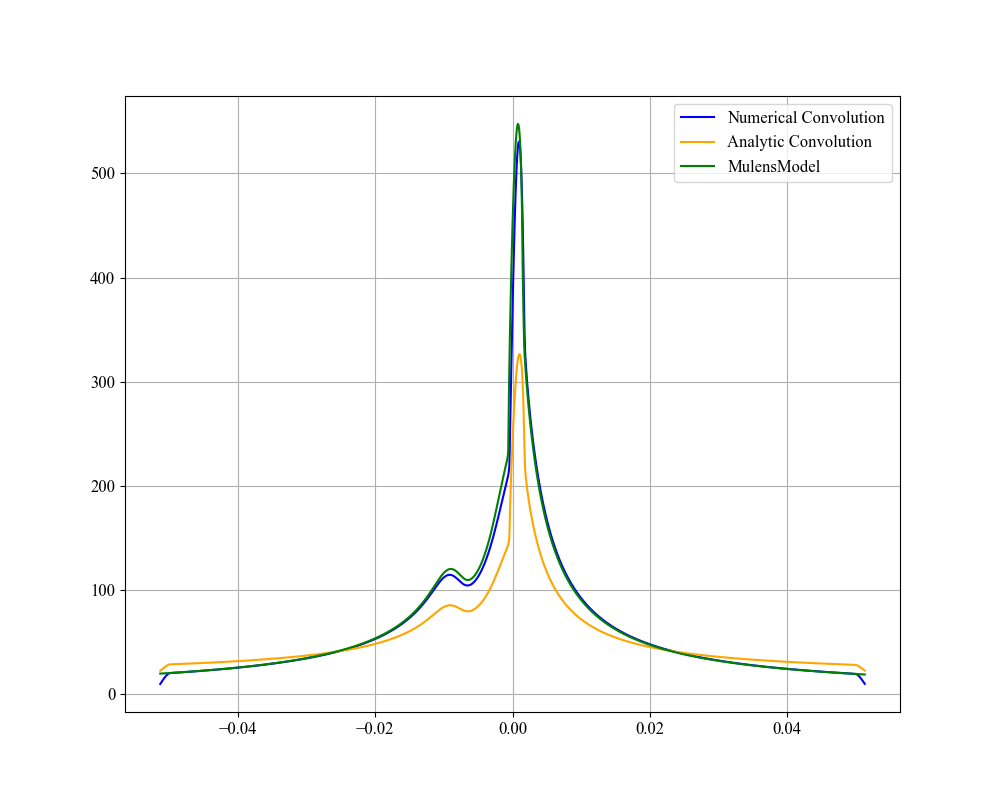

In [ ]:
mm_param_dict = {'t_0': 0, 't_E': 1, 'u_0': u, 'rho': radius, 'q': 1e-3, 'alpha': alpha, 's': 0.8}
model = mm.Model(mm_param_dict)

model.set_default_magnification_method('VBBL')

mm_brightnesses = model.get_magnification(numerical_times, gamma=0.5)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.plot(numerical_times, numerical_brightnesses, label='Numerical Convolution', color='blue')
ax.plot(analytic_times, analytic_brightnesses, label='Analytic Convolution', color='orange')
ax.plot(numerical_times, mm_brightnesses, label='MulensModel', color='green')

ax.grid()
ax.legend()

plt.show()

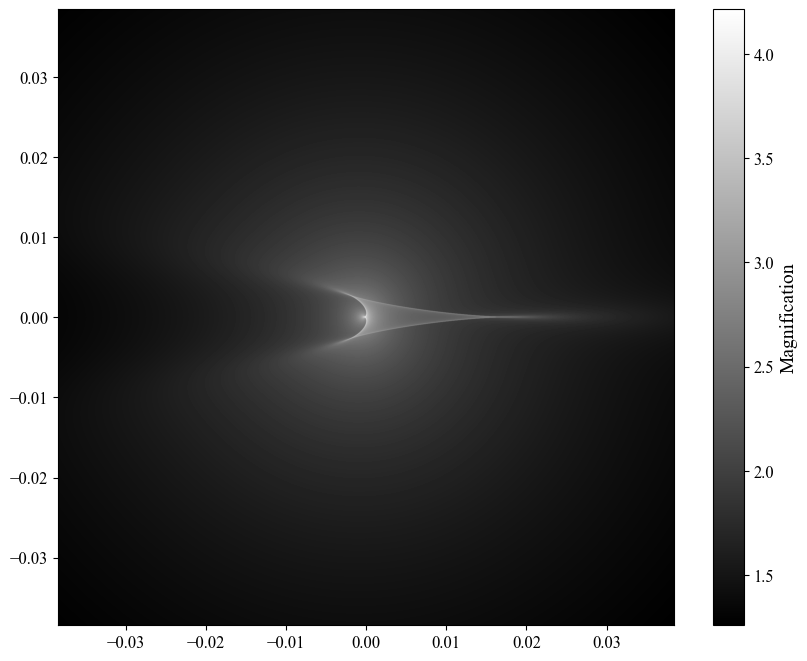

In [ ]:
highres_image = zoom(image, scale_factor, order=1)  # bilinear interpolation

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

img = ax.imshow(np.log10(highres_image), cmap='grey', extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2])
plt.colorbar(img, ax=ax, label='Magnification')

plt.show()